## Setup

In [1]:
!pip install pytorch_optimizer
!pip install torchview

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.1/269.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 105.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Set seed for reproducibility
SEED = 42

In [3]:

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
import pytorch_optimizer as optim
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
from torchvision.transforms import InterpolationMode
from torchview import draw_graph

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import requests
from io import BytesIO
import cv2
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import re
import pandas as pd

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.6.0+cu124
Device: cuda


## Data Loading

In [6]:
def load_images_from_folder(folder):
    
    img_mask = {}

    # Iterate through files in the specified folder
    for i, filename in enumerate(os.listdir(folder)):
        img = cv2.imread(os.path.join(folder, filename))

        is_img = filename.startswith("img")
        
        key = re.search(r"(\d+)", filename).group(1)

        if key not in img_mask:
            img_mask[key] = [None, None]
        
        # Convert image from BGR to RGB
        img = img[...,::-1]

        dim = max(img.shape[:-1])

        # Convert to PIL
        pil_img = Image.fromarray(img)

        # Padding

        padded = ImageOps.pad(pil_img, (dim, dim))

        # Convert back to NumPy Array

        img = np.array(padded)

        # Resize the image
        if(is_img):
            img = cv2.resize(img, (256, 256), interpolation=cv2.INTER_AREA)
        else:
             img = cv2.resize(img, (256, 256))

        # Normalize image pixel values to a float range [0, 1]
        img = (img / 255).astype(np.float32)

        if is_img:
            img_mask[key][0] = img
        else:
            img_mask[key][1] = img

        if i%100 == 0:
            print(i)
        

    return img_mask

# Load images from the folder
path = '/kaggle/input/an2dl2526c2v2/train_data'

cells = load_images_from_folder(path)

print(f"Loaded {len(cells)} pairs")

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
Loaded 631 pairs


In [7]:
path = '/kaggle/input/an2dl2526c2v2/test_data'
test_cells = load_images_from_folder(path)
print(f"Loaded {len(test_cells)} pairs")

0
100
200
300
400
500
600
700
800
900
Loaded 477 pairs


In [8]:
labels = pd.read_csv("/kaggle/input/an2dl2526c2v2/train_labels.csv")

## Data Preprocessing

In [9]:
print(labels.shape)

(631, 2)


In [10]:
print(labels.head())

   sample_index            label
0  img_0000.png  Triple negative
1  img_0001.png        Luminal B
2  img_0002.png        Luminal B
3  img_0003.png        Luminal B
4  img_0004.png        Luminal B


In [11]:
labels_map = {
    "Triple negative" : 0,
    "Luminal A"       : 1,
    "Luminal B"       : 2,
    "HER2(+)"         : 3
}

In [12]:
labels["sample_index"] = labels["sample_index"].str.extract(r"(\d+)(?=\.png)")

In [13]:
valid_indices = set(cells.keys())

labels = labels[labels["sample_index"].isin(valid_indices)].copy()

In [14]:
print(labels.head())

  sample_index            label
0         0000  Triple negative
1         0001        Luminal B
2         0002        Luminal B
3         0003        Luminal B
4         0004        Luminal B


In [15]:
y_train_val = np.array(labels['label'])

In [16]:
print(y_train_val.shape)
y_train_val = y_train_val.reshape(-1, 1)
print(y_train_val.shape)

(631,)
(631, 1)


In [17]:
print(y_train_val.shape)


(631, 1)


In [18]:
vec_map = np.vectorize(labels_map.get)
y_train_val = vec_map(y_train_val)   

In [19]:
print(y_train_val.shape)

(631, 1)


In [20]:
print(cells['0000'][0].shape)
print(cells['0000'][1].shape)

(256, 256, 3)
(256, 256, 3)


In [21]:
for cell in cells:
    cells[cell][1] = np.expand_dims( cells[cell][1][:, :, 0], axis=-1)

In [22]:
for cell in test_cells:
    test_cells[cell][1] = np.expand_dims( test_cells[cell][1][:, :, 0], axis=-1)

In [23]:
print(cells['0000'][1].shape)

(256, 256, 1)


In [25]:
train_images = []
train_masks = []

    
for cell in sorted(cells, key=lambda k: int(k)):
    train_images.append(cells[cell][0])
    train_masks.append(cells[cell][1])
    
    
train_images = np.array(train_images)
train_masks = np.array(train_masks)

In [26]:
test_images = []
test_keys = []
test_masks = []

    
for cell in sorted(test_cells, key=lambda k: int(k)):
    test_images.append(test_cells[cell][0])
    test_masks.append(test_cells[cell][1])
    test_keys.append(cell)
    
test_images = np.array(test_images)
test_masks = np.array(test_masks)

## Data Visualization

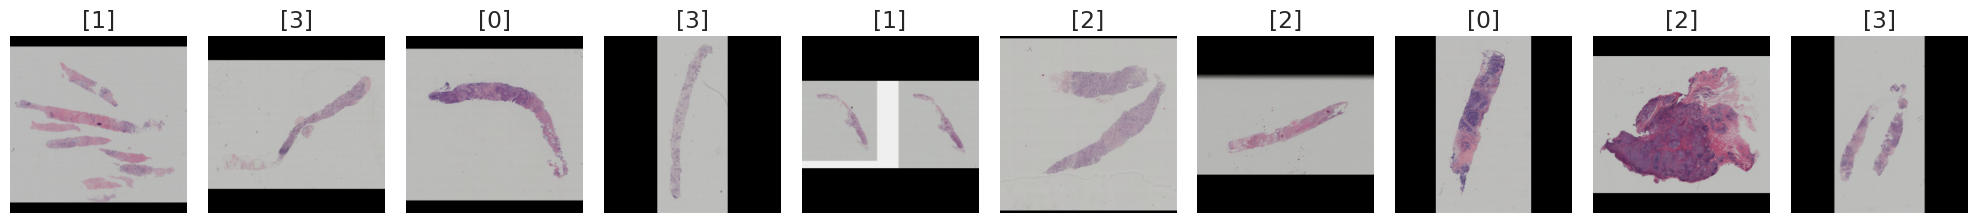

In [27]:
# Display a sample of images from the training-validation dataset
num_img = 10
random_indices = random.sample(range(len(train_images)), num_img)

fig, axes = plt.subplots(1, num_img, figsize=(20, 20))

# Iterate through the selected number of images
for i, idx in enumerate(random_indices):
    ax = axes[i % num_img]
    ax.imshow(np.squeeze(train_images[idx]), vmin=0., vmax=1.)
    ax.set_title(f'{y_train_val[idx]}')
    ax.axis('off')

# Adjust layout and display the images
plt.tight_layout()
plt.show()

In [28]:
print(train_images.shape)

(631, 256, 256, 3)


In [29]:
print(test_images.shape)

(477, 256, 256, 3)


## Dataset Preparation

In [422]:
# Split data into training and validation sets, maintaining class distribution
X_train_img, X_val_img, X_train_mask, X_val_mask, y_train, y_val = train_test_split(train_images, train_masks, y_train_val, random_state=SEED, test_size=0.3, stratify=y_train_val)

# Print the shapes of the resulting datasets
print("Training images Shape:", X_train_img.shape)
print("Training masks Shape:", X_train_mask.shape)
print("Training Label Shape:", y_train.shape)

print("Validation images Shape:", X_val_img.shape)
print("Validation masks Shape:", X_val_mask.shape)
print("Validation Label Shape:", y_val.shape)

Training images Shape: (441, 256, 256, 3)
Training masks Shape: (441, 256, 256, 1)
Training Label Shape: (441, 1)
Validation images Shape: (190, 256, 256, 3)
Validation masks Shape: (190, 256, 256, 1)
Validation Label Shape: (190, 1)


In [423]:
mean = X_train_img.mean(axis=(0, 1, 2))
std = X_train_img.std(axis=(0, 1, 2))

print("Mean:", mean)
print("Std:", std)

Mean: [0.52191126 0.51195693 0.5191522 ]
Std: [0.28402385 0.28412297 0.28411546]


In [424]:
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

{0: 54, 1: 122, 2: 154, 3: 111}


In [425]:
class_counts = torch.tensor(counts, dtype=torch.float)
weights = 1.0 / class_counts
weights = weights / weights.sum()  # normalize

In [426]:
# Define the input shape based on the training data
input_shape = (X_train_img.shape[3], X_train_img.shape[1], X_train_img.shape[2])
mask_shape = (X_train_mask.shape[3], X_train_mask.shape[1], X_train_mask.shape[2])

# Define the number of classes based on the categorical labels
num_classes = len(np.unique(y_train))

In [427]:
print(input_shape)
print(mask_shape)
print(num_classes)

(3, 256, 256)
(1, 256, 256)
4


In [428]:
class AugmentedDataset(torch.utils.data.Dataset):

    def __init__(self, images, masks, labels, transform_img=None, transform=None):
        self.images = images
        self.masks = masks
        self.labels = labels
        self.transform_img = transform_img
        self.transform = transform
        # Base transform for image
        self.to_tensor_img = transforms.Compose([
            transforms.ToImage(),  
            transforms.ToDtype(torch.float32, scale=True)
        ])

        # Base transform for mask
        self.to_tensor_mask = transforms.Compose([
            transforms.ToImage(),  
            transforms.ToDtype(torch.float32, scale=True)
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Get image and label
        image = self.images[idx]
        mask = self.masks[idx]
        label = self.labels[idx]

        # Convert numpy to PIL Image
        image_pil = Image.fromarray((image * 255).astype(np.uint8))

        if mask.ndim == 2:  # H x W
            mask_pil = Image.fromarray((mask * 255).astype(np.uint8))
        else:               # H x W x 1
            mask_pil = Image.fromarray((mask.squeeze(-1) * 255).astype(np.uint8))

        # Convert to tensor using v2 recommended approach
        image_tensor = self.to_tensor_img(image_pil)
        mask_tensor = self.to_tensor_mask(mask_pil)

        if self.transform:
            image_tensor, mask_tensor = self.transform(image_tensor, mask_tensor)
        
        if self.transform_img:
            image_tensor = self.transform_img(image_tensor)

        

        return image_tensor, mask_tensor, torch.tensor(label, dtype=torch.long)

In [429]:
# Define data augmentation pipeline for training using transforms v2
common_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(3),
])

In [430]:
img_augmentation = transforms.Compose([
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

In [431]:
# Create augmented datasets
train_ds = AugmentedDataset(X_train_img, X_train_mask, y_train.squeeze(), transform=common_augmentation, transform_img = img_augmentation)
val_ds = AugmentedDataset(X_val_img, X_val_mask, y_val.squeeze(), transform=None)
test_ds = TensorDataset(torch.from_numpy(test_images).permute(0, 3, 1, 2), torch.from_numpy(test_masks).permute(0, 3, 1, 2), torch.tensor([int(k) for k in test_keys]))


In [432]:
# Convert numpy arrays to PyTorch datasets (pairs features with labels)
#test_ds = TensorDataset(torch.from_numpy(test_images).permute(0, 3, 1, 2), torch.from_numpy(test_masks).permute(0, 3, 1, 2), torch.tensor([int(k) for k in test_keys]))

In [433]:
# Define the batch size, which is the number of samples in each batch
BATCH_SIZE = 16

In [434]:
def make_loader(ds, batch_size, shuffle, drop_last):
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [435]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [436]:
test_loader   = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

## Model Configuration

In [437]:
# Training parameters
LEARNING_RATE = 3e-5
EPOCHS = 200
PATIENCE = 50

# Regularization
DROPOUT_RATE = 0.3

# Set up loss function
criterion = nn.CrossEntropyLoss(weight=weights.to(device))

# Print the defined parameters
print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)
print("Learning Rate:", LEARNING_RATE)
print("Dropout Rate:", DROPOUT_RATE)
print("Patience:", PATIENCE)

Epochs: 200
Batch Size: 16
Learning Rate: 3e-05
Dropout Rate: 0.3
Patience: 50


In [438]:
# CNN Architecture parameters
# Number of convolutional blocks
NUM_BLOCKS = 1

# Number of conv layers per block
CONVS_PER_BLOCK = 1

# Use strided convolutions instead of pooling
USE_STRIDE = False

# Stride value when USE_STRIDE is True
STRIDE_VALUE = 2

# Padding size
PADDING_SIZE = 1

# Pooling size when USE_STRIDE is False
POOL_SIZE = 2

# Number of channels in first block
INITIAL_CHANNELS = 32

# Channel multiplication factor between blocks
CHANNEL_MULTIPLIER = 2

print("Num Blocks:", NUM_BLOCKS)
print("Convs per Block:", CONVS_PER_BLOCK)
print("Use Stride:", USE_STRIDE)
print("Stride Value:", STRIDE_VALUE)
print("Padding Size:", PADDING_SIZE)
print("Pool Size:", POOL_SIZE)
print("Initial Channels:", INITIAL_CHANNELS)
print("Channel Multiplier:", CHANNEL_MULTIPLIER)

Num Blocks: 1
Convs per Block: 1
Use Stride: False
Stride Value: 2
Padding Size: 1
Pool Size: 2
Initial Channels: 32
Channel Multiplier: 2


In [439]:
# Single convolutional block with multiple conv layers, ReLU and pooling/stride
class VanillaCNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, in_mask_channels, out_mask_channels, num_convs=1, use_stride=False, stride_value=2, padding_size=1, pool_size=2):
        super().__init__()

        img_layers = []
        mask_layers = []

        # First convolution: in_channels -> out_channels
        if num_convs == 1:
            # Single conv: apply stride here if use_stride is True
            stride = stride_value if use_stride else 1
            img_layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=padding_size, stride=stride))
            mask_layers.append(nn.Conv2d(in_mask_channels, out_mask_channels, kernel_size=3, padding=padding_size, stride=stride))
        else:
            # Multiple convs: first one always has stride=1
            img_layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=1))
            mask_layers.append(nn.Conv2d(in_mask_channels, out_mask_channels, kernel_size=3, padding=1, stride=1))

            # Intermediate convolutions (all with stride=1)
            for i in range(1, num_convs - 1):
                img_layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1))
                mask_layers.append(nn.Conv2d(out_mask_channels, out_mask_channels, kernel_size=3, padding=1, stride=1))

            # Last convolution: apply stride here if use_stride is True
            stride = stride_value if use_stride else 1
            img_layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=padding_size, stride=stride))
            mask_layers.append(nn.Conv2d(out_mask_channels, out_mask_channels, kernel_size=3, padding=padding_size, stride=stride))

        # Layer Norm
        img_layers.append(nn.GroupNorm(1, out_channels))
        mask_layers.append(nn.GroupNorm(1, out_channels))
        
        # ReLU activation
        img_layers.append(nn.ReLU())
        mask_layers.append(nn.ReLU())

        # Pooling only if not using stride for spatial reduction
        if not use_stride:
            img_layers.append(nn.MaxPool2d(kernel_size=pool_size, stride=pool_size))
            mask_layers.append(nn.MaxPool2d(kernel_size=pool_size, stride=pool_size))

        self.img_block = nn.Sequential(*img_layers)
        self.mask_block = nn.Sequential(*mask_layers)

    def forward(self, x_img, x_mask):
        return self.img_block(x_img), self.mask_block(x_mask)

# Convolutional Neural Network architecture 
class CNN(nn.Module):
    def __init__(self, input_shape=(3,32,32), mask_shape=(1,32,32), num_classes=4, dropout_rate=DROPOUT_RATE,
                 num_blocks=NUM_BLOCKS, convs_per_block=CONVS_PER_BLOCK,
                 use_stride=USE_STRIDE, stride_value=STRIDE_VALUE, padding_size=PADDING_SIZE, pool_size=POOL_SIZE,
                 initial_channels=INITIAL_CHANNELS, channel_multiplier=CHANNEL_MULTIPLIER):
        super().__init__()

        # Build convolutional blocks
        blocks = []
        in_channels = input_shape[0]
        out_channels = initial_channels
        in_mask_channels = mask_shape[0]
        out_mask_channels = initial_channels

        for i in range(num_blocks):
            blocks.append(VanillaCNNBlock(
                in_channels=in_channels,
                out_channels=out_channels,
                in_mask_channels = in_mask_channels,
                out_mask_channels = out_mask_channels,
                num_convs=convs_per_block,
                use_stride=use_stride,
                stride_value=stride_value,
                padding_size=padding_size,
                pool_size=pool_size
            ))

            

            # Prepare for next block: increase channels
            in_channels = out_channels
            out_channels = out_channels * channel_multiplier
            in_mask_channels = out_mask_channels
            out_mask_channels = out_mask_channels * channel_multiplier

        self.blocks = nn.ModuleList(blocks)

        # Calculate flattened size after all blocks using a dummy forward pass
        # This approach is robust and works with any configuration of padding, stride, and pooling
        with torch.no_grad():
            dummy_img = torch.zeros(1, *input_shape)
            dummy_mask = torch.zeros(1, *mask_shape)
            out_img, out_mask = self._run_blocks(dummy_img, dummy_mask)
            flat_img = out_img.numel()
            flat_mask = out_mask.numel()

        # Classification head: flatten features and apply dropout before final layer
        self.classifier_head = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(flat_img + flat_mask, num_classes)
        )

    def _run_blocks(self, img, mask):
        for block in self.blocks:
            img, mask = block(img, mask)
        return img, mask
    
    # Forward pass through the network
    def forward(self, x_img, x_mask):

        img_feat, mask_feat = self._run_blocks(x_img, x_mask)
        
        combined = torch.cat([
            img_feat.view(img_feat.size(0), -1),
            mask_feat.view(mask_feat.size(0), -1)
        ], dim=1)
        x = self.classifier_head(combined)
        return x

## Model

In [440]:
# Instantiate CNN model and move to computing device (CPU/GPU)
cnn_model = CNN(
    input_shape,
    mask_shape,
    num_classes,
    num_blocks=NUM_BLOCKS,
    convs_per_block=CONVS_PER_BLOCK,
    use_stride=USE_STRIDE,
    stride_value=STRIDE_VALUE,
    padding_size=PADDING_SIZE,
    pool_size=POOL_SIZE,
    initial_channels=INITIAL_CHANNELS,
    channel_multiplier=CHANNEL_MULTIPLIER
    ).to(device)

## Training

In [441]:
# Setup training
optimizer = optim.Ranger(cnn_model.parameters(), lr=LEARNING_RATE)
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

In [442]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [443]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs_img, inputs_mask, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs_img, inputs_mask, targets = inputs_img.to(device), inputs_mask.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs_img, inputs_mask)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs_img.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [444]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs_img, inputs_mask, targets in val_loader:
            # Move data to device
            inputs_img, inputs_mask, targets = inputs_img.to(device), inputs_mask.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs_img, inputs_mask)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs_img.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [445]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

In [446]:
os.makedirs("models", exist_ok=True)

In [447]:
%%time
# Train model and track training history
cnn_model, training_history = fit(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    verbose=1,
    experiment_name="cnn",
    evaluation_metric="val_f1",
    mode='max',
    patience=PATIENCE
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = cnn_model
    best_performance = training_history['val_f1'][-1]

Training 200 epochs...
Epoch   1/200 | Train: Loss=5.8183, F1 Score=0.1285 | Val: Loss=2.1935, F1 Score=0.1791
Epoch   2/200 | Train: Loss=2.1287, F1 Score=0.3090 | Val: Loss=1.7322, F1 Score=0.1973
Epoch   3/200 | Train: Loss=1.4790, F1 Score=0.3049 | Val: Loss=1.3944, F1 Score=0.3045
Epoch   4/200 | Train: Loss=1.4012, F1 Score=0.3141 | Val: Loss=1.4005, F1 Score=0.2628
Epoch   5/200 | Train: Loss=1.3713, F1 Score=0.3269 | Val: Loss=1.4397, F1 Score=0.1946
Epoch   6/200 | Train: Loss=1.3447, F1 Score=0.3565 | Val: Loss=1.5491, F1 Score=0.0782
Epoch   7/200 | Train: Loss=1.3674, F1 Score=0.3470 | Val: Loss=1.4081, F1 Score=0.2099
Epoch   8/200 | Train: Loss=1.3511, F1 Score=0.3377 | Val: Loss=1.5283, F1 Score=0.1463
Epoch   9/200 | Train: Loss=1.3407, F1 Score=0.3719 | Val: Loss=1.4106, F1 Score=0.3184
Epoch  10/200 | Train: Loss=1.3091, F1 Score=0.3685 | Val: Loss=1.4774, F1 Score=0.1877
Epoch  11/200 | Train: Loss=1.3093, F1 Score=0.4190 | Val: Loss=1.6269, F1 Score=0.1695
Epoch  12

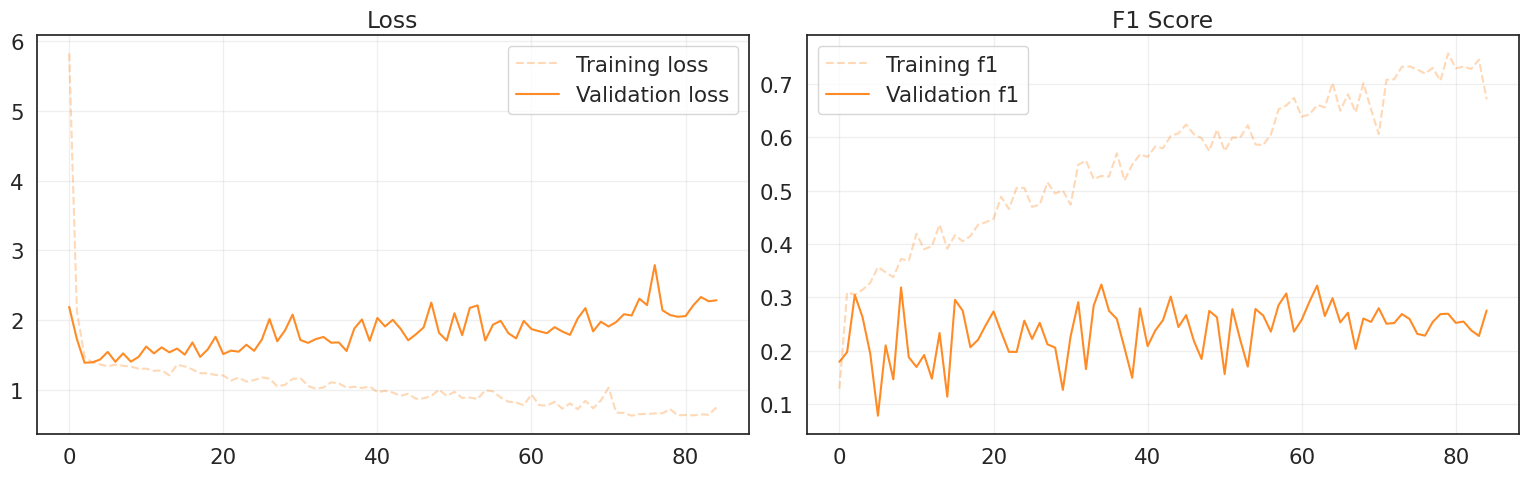

In [448]:
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.3684
Precision over the validation set: 0.3802
Recall over the validation set: 0.3684
F1 score over the validation set: 0.3243


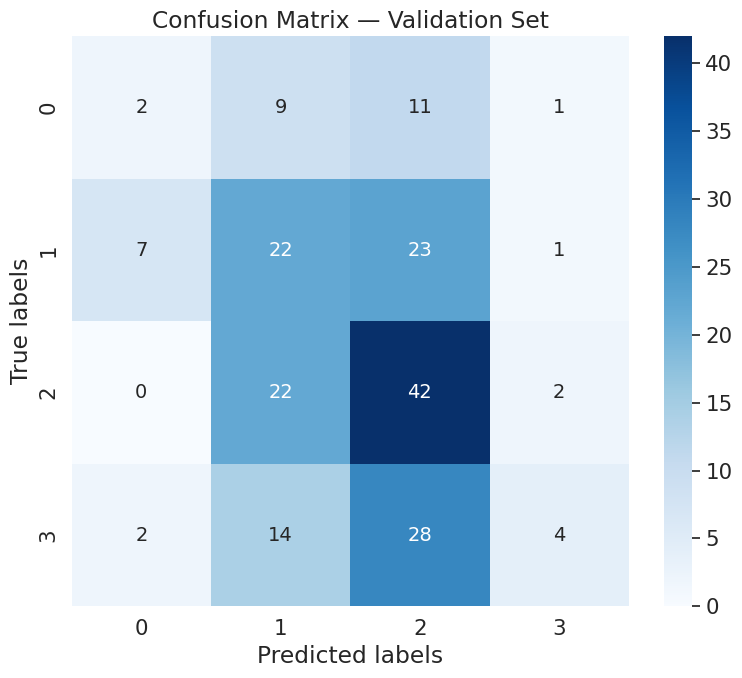

In [449]:
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb_img, xb_mask, yb in val_loader:
        xb_img = xb_img.to(device)
        xb_mask = xb_mask.to(device)

        # Forward pass: get model predictions
        logits = cnn_model(xb_img, xb_mask)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

## Evaluation

In [450]:
cnn_model.eval()

# Lists to store predictions
sample_indices = []
predictions = []


In [451]:
int_to_label = {
     0 : "Triple negative",
     1 : "Luminal A",
     2 : "Luminal B",
     3 : "HER2(+)"
}

In [452]:
# Generate predictions
with torch.no_grad():  # Disable gradient computation for inference

    
    for i, (batch_img, batch_mask, keys) in enumerate(test_loader):

        
        xb_img = batch_img
        xb_mask = batch_mask

        
        xb_img = xb_img.to(device).float()
        xb_mask = xb_mask.to(device).float()
        keys = keys.to(device)

        batch_size = xb_img.shape[0]

        
        #Get model predictions
        output = cnn_model(xb_img, xb_mask)
        probabilities = torch.softmax(output, dim=1)
        batch_preds = probabilities.argmax(dim=1).cpu().numpy()
    

        for j, pred_idx in enumerate(batch_preds):
            filename = f"img_{keys[j]:04d}.png"
            pred_class = int_to_label[int(pred_idx)]

            sample_indices.append(filename)
            predictions.append(pred_class)

submission_df = pd.DataFrame({
    'sample_index': sample_indices,
    'label': predictions
})

In [453]:
os.makedirs("/kaggle/working/submissions", exist_ok=True)

In [454]:
submission_df.to_csv('/kaggle/working/submissions/cnn_from_scratch.csv', index=False)